# Setup

In [1]:
# Standard library imports
import os
import warnings

# Backend selection - this line MUST run before `import keras`
os.environ['KERAS_BACKEND'] = 'torch'

# Third-party imports: core data -> deep learning -> visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import keras
from keras import layers, ops

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA

# Configuration & settings
warnings.simplefilter(action='ignore', category=FutureWarning)

This section of code prepares the environment for a machine learning project, specifically one that will utilize both Keras and scikit-learn libraries.

First, it imports necessary modules from Python’s standard library: `os` for interacting with the operating system (like setting environment variables), and `warnings` to manage warning messages. 

Next, it sets the Keras backend to 'torch'. This is a crucial step that *must* happen before importing the main Keras module because it determines which deep learning framework Keras will use under the hood – in this case, PyTorch.

Following that, several third-party libraries are imported. `numpy` provides support for numerical operations and arrays; `pandas` enables data manipulation and analysis using DataFrames; and `matplotlib.pyplot` is used for creating visualizations like plots and charts. 

The code also imports core components of PyTorch (`torch`) and Keras (`keras`), including specific modules within Keras such as `layers` (for building neural network layers) and `ops` (for operations). 

Additionally, it imports tools from scikit-learn: `LogisticRegression` and `KNeighborsClassifier` for traditional machine learning algorithms, and `PCA` for dimensionality reduction.

Finally, the code configures warning behavior by suppressing `FutureWarning` messages. These warnings often indicate that a feature is deprecated or will change in future versions of a library, and ignoring them can simplify output during development.

In [2]:
# general settings
class CFG:
    data_folder     = './data/'
    graph_folder    = './graphs/'
    img_dim1        = 16
    img_dim2        = 6
    SEED            = 42
    # problem shape
    label_fraction  = 0.05   # what part of the training labels we allow ourselves to keep
    conf_threshold  = 0.95   # confidence required to accept a pseudo-label
    # training lengths
    batch_size      = 128    # for anything trained on the full (unlabeled) pool
    small_batch     = 32     # for anything trained on the tiny labeled subset
    sup_epochs      = 40     # training on the full pool (thousands of series)
    small_epochs    = 100    # training on the tiny labeled subset (180 series)
    pretrain_epochs = 30     # self-supervised pretext training
    finetune_epochs = 50     # fine-tuning a pretrained encoder

# display style
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (CFG.img_dim1, CFG.img_dim2)

np.random.seed(CFG.SEED)

# device: the Apple-silicon GPU if one is present, plain CPU otherwise
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"Keras {keras.__version__} on the '{keras.backend.backend()}' backend, device: {DEVICE}")

Keras 3.15.0 on the 'torch' backend, device: mps


This code defines configuration settings and initializes some global parameters for a machine learning project.

A class named `CFG` is created to hold these settings as attributes, making them easily accessible throughout the program. It specifies paths for data (`data_folder`) and graphs (`graph_folder`), image dimensions (`img_dim1`, `img_dim2`), and a random seed (`SEED`) for reproducibility. 

Several parameters relate to the problem itself: `label_fraction` determines how much of the training data will have labels, `conf_threshold` sets the confidence level needed to accept automatically generated pseudo-labels.

Training lengths are also defined: `batch_size` and `small_batch` control the number of samples used in each training iteration for different datasets (full vs. small labeled), while `sup_epochs`, `small_epochs`, `pretrain_epochs`, and `finetune_epochs` specify the number of training iterations for various stages like supervised learning, training on a small labeled set, self-supervised pretraining, and fine-tuning.

The code then adjusts the plotting style using Matplotlib by applying the 'seaborn-v0_8' theme and setting the default figure size based on `img_dim1` and `img_dim2`. 

It sets the random seed for NumPy to ensure consistent results.

Finally, it determines the computational device to use: if an Apple Silicon GPU with Metal Performance Shaders (MPS) is available, it will be used (`DEVICE = 'mps'`); otherwise, it defaults to the CPU (`DEVICE = 'cpu'`). A message is printed to the console indicating the Keras version, backend, and selected device.

# Utils

In [3]:
def load_forda(split):
    """Load one split of the FordA dataset from a tab-separated file."""
    arr = np.loadtxt(CFG.data_folder + f'FordA_{split}.tsv', delimiter='\t')
    y = (arr[:, 0] == 1).astype(int)        # first column holds the label (-1 or 1)
    X = arr[:, 1:][..., np.newaxis]         # the rest is the signal; add a channel axis
    return X, y

This code defines a function called `load_forda` that loads data from the FordA dataset.

The function takes one argument, `split`, which specifies which portion of the dataset to load (e.g., 'train', 'validation', or 'test'). It constructs the file path by combining the `data_folder` attribute from the `CFG` object with the split name and the '.tsv' extension.

It then uses `np.loadtxt` to read the data from the tab-separated value (TSV) file into a NumPy array named `arr`. 

The labels (`y`) are extracted from the first column of the array (`arr[:, 0]`). The code checks if the values in this column are equal to 1, converting the result to integers (1 for positive class, 0 for negative class).

The signal data (`X`) is taken from all columns except the first one (`arr[:, 1:]`). A new axis is added at the end using `np.newaxis` to represent a single channel, effectively reshaping the data to have dimensions suitable for time series analysis or input into a neural network expecting a channel dimension.

Finally, the function returns the signal data `X` and corresponding labels `y`.

In [4]:
def make_labeled_split(y, fraction, seed):
    """Pretend only `fraction` of the training labels exist.

    Returns a boolean mask: True = we keep this label, False = we hide it.
    The choice is stratified, so both classes are equally represented.
    """
    rng = np.random.default_rng(seed)
    n_per_class = int(len(y) * fraction) // 2
    mask = np.zeros(len(y), dtype=bool)
    for c in [0, 1]:
        idx_c = np.where(y == c)[0]
        mask[rng.choice(idx_c, size=n_per_class, replace=False)] = True
    return mask

This code defines a function called `make_labeled_split` that simulates a scenario where only a fraction of the training labels are available.

The function takes three arguments: `y` (the array of labels), `fraction` (the desired proportion of labeled data), and `seed` (for reproducibility). It aims to create a boolean mask indicating which labels should be kept (True) and which should be hidden (False), while maintaining a balanced representation of both classes.

It initializes a random number generator (`rng`) using the provided seed for consistent results. The number of samples to keep per class is calculated as `n_per_class`, ensuring that approximately half of the selected labels come from each class. 

A boolean array named `mask` is created, initially filled with False values. The code then iterates through both classes (0 and 1). For each class, it finds the indices (`idx_c`) where the corresponding label exists in the `y` array. It randomly selects `n_per_class` indices from these without replacement using `rng.choice`, and sets the corresponding elements in the `mask` to True.

Finally, the function returns the `mask` array, which can be used to filter the labeled data.

In [5]:
def jitter(X, rng, sigma=0.2):
    """Add small Gaussian noise to every point of the series."""
    return X + rng.normal(0, sigma, X.shape)

def scaling(X, rng, sigma=0.15):
    """Multiply each whole series by a random factor close to 1."""
    return X * rng.normal(1, sigma, (len(X), 1, 1))

def permute_segments(X, rng, n_seg=8):
    """Chop each series into segments and shuffle their order."""
    Xp = np.empty_like(X)
    segs = np.array_split(np.arange(X.shape[1]), n_seg)
    for i in range(len(X)):
        order = rng.permutation(n_seg)
        Xp[i] = X[i][np.concatenate([segs[j] for j in order])]
    return Xp

def weak_aug(X, rng):
    """Weak view: jitter + scaling (shape-preserving)."""
    return scaling(jitter(X, rng), rng)

def strong_aug(X, rng):
    """Strong view: segment permutation + jitter (shape-destroying)."""
    return jitter(permute_segments(X, rng), rng)

This code defines a set of data augmentation functions designed to create different variations of time series data. These augmentations are used to improve the robustness and generalization ability of machine learning models.

`jitter(X, rng, sigma=0.2)`: This function adds small Gaussian noise to each point in the input time series `X`. The amount of noise is controlled by the standard deviation `sigma`, which defaults to 0.2. It uses a random number generator (`rng`) to generate the noise.

`scaling(X, rng, sigma=0.15)`: This function multiplies each entire time series by a random factor close to 1. The scaling factor is drawn from a normal distribution with a mean of 1 and a standard deviation `sigma`, which defaults to 0.15.  This introduces variations in the amplitude of the signal.

`permute_segments(X, rng, n_seg=8)`: This function divides each time series into `n_seg` (defaulting to 8) segments and then randomly shuffles the order of these segments. This disrupts the temporal structure of the data while preserving the overall content.

`weak_aug(X, rng)`: This function applies a combination of jitter and scaling augmentations to create a "weak" view of the data – transformations that preserve the basic shape of the time series. It first jitters the data and then scales it.

`strong_aug(X, rng)`: This function creates a “strong” view by applying segment permutation followed by jittering. These are considered more disruptive augmentations as they alter the temporal order of segments in addition to adding noise. 

These functions all take the time series data `X` and a random number generator `rng` as input, allowing for reproducible augmentation when using the same seed. They return the augmented version of the data.

In [6]:
def mask_patches(X, rng, patch_len=25, n_patches=5, pointwise=False, mask_frac=0.25):
    """Zero out parts of each series; return the masked copy and the mask itself.

    pointwise=False : hide `n_patches` contiguous stretches of `patch_len` steps
    pointwise=True  : hide a random `mask_frac` of individual time steps
    """
    Xm = X.copy()
    M = np.zeros(X.shape, dtype=bool)
    if pointwise:
        M = rng.random(X.shape) < mask_frac
    else:
        for i in range(len(X)):
            for _ in range(n_patches):
                s = rng.integers(0, X.shape[1] - patch_len)
                M[i, s:s + patch_len, :] = True
    Xm[M] = 0.0
    return Xm, M

This code defines a function called `mask_patches` that introduces masking to time series data by zeroing out portions of the signal. It returns both the masked data and a boolean mask indicating which elements were masked.

The function takes several arguments: `X` (the input time series data), `rng` (a random number generator), `patch_len` (the length of contiguous stretches to mask, defaulting to 25), `n_patches` (the number of patches to mask per series, defaulting to 5), `pointwise` (a boolean flag controlling the masking strategy), and `mask_frac` (the fraction of individual time steps to mask when `pointwise` is True, defaulting to 0.25).

First, it creates a copy of the input data `X` called `Xm` to avoid modifying the original data in place. It also initializes a boolean array `M` with the same shape as `X`, filled with False values – this will serve as the mask.

If `pointwise` is True, it generates random numbers between 0 and 1 for each element of `X` using `rng.random`. Elements where the generated number is less than `mask_frac` are set to True in the mask `M`, effectively masking a random fraction of individual time steps.

If `pointwise` is False (the default), it iterates through each time series in `X`. For each series, it repeats the following process `n_patches` times: It randomly selects a starting index `s` within the valid range to ensure that a patch of length `patch_len` can be extracted. Then, it sets the corresponding slice of the mask `M` to True, indicating that this segment should be masked.

Finally, it sets all elements in `Xm` where the mask `M` is True to 0.0, effectively zeroing out the selected patches or individual time steps. The function returns both the masked data `Xm` and the boolean mask `M`.

In [7]:
def build_encoder(pooled=True):
    """The shared convolutional backbone used by every deep model in this notebook.

    pooled=True  -> output is one 64-number embedding per series
    pooled=False -> output keeps the time axis: one 64-number vector per time step
    """
    inp = keras.Input(shape=(SEQ_LEN, 1))
    x = inp
    for dilation in [1, 4, 16]:
        x = layers.Conv1D(64, 3, padding='same', dilation_rate=dilation)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
    if pooled:
        x = layers.GlobalAveragePooling1D()(x)
    return keras.Model(inp, x)

def build_classifier(encoder=None):
    """Encoder + a softmax head. If no encoder is given, a fresh one is built."""
    if encoder is None:
        encoder = build_encoder(pooled=True)
    inp = keras.Input(shape=(SEQ_LEN, 1))
    h = encoder(inp)
    if len(h.shape) == 3:                       # sequence-shaped encoder: pool it
        h = layers.GlobalAveragePooling1D()(h)
    out = layers.Dense(2, activation='softmax')(h)
    return keras.Model(inp, out)

This code defines two functions for building neural network models – an encoder and a classifier – specifically designed for time series data.

`build_encoder(pooled=True)`: This function constructs the convolutional backbone of the model, responsible for extracting features from the input time series. It takes a boolean argument `pooled`, which determines whether to output a single embedding vector per series or retain the time axis in the output. 

It starts by defining an input layer (`inp`) with a shape of (SEQ_LEN, 1), representing a time series of length SEQ_LEN with one channel. The code then applies a series of convolutional layers (`Conv1D`) with increasing dilation rates (1, 4, and 16). Dilation allows the network to capture patterns at different temporal scales. Each convolutional layer is followed by batch normalization (`BatchNormalization`) and ReLU activation (`ReLU`). If `pooled` is True (the default), a global average pooling layer (`GlobalAveragePooling1D`) is applied to reduce the output to a single 64-number embedding vector per series. Finally, it returns a Keras model that takes the input time series and outputs either the pooled embedding or the sequence of feature vectors.

`build_classifier(encoder=None)`: This function builds a classifier on top of the encoder. It takes an optional `encoder` argument; if no encoder is provided, it creates a new one using `build_encoder(pooled=True)`. 

It defines an input layer (`inp`) with the same shape as in `build_encoder`. The input is passed through the encoder to obtain feature representations (`h`). If the output of the encoder has three dimensions (meaning it's sequence-shaped), a global average pooling layer is applied to reduce it to a single vector. Finally, a dense layer (`Dense`) with two outputs and a softmax activation function is added to produce probabilities for each class. The function returns a Keras model that takes the input time series and outputs the predicted class probabilities.

In [8]:
scores = {}   # method name -> test accuracy, filled in as we go

def fit_classifier(X, y, epochs, batch_size, encoder=None, lr=1e-3, verbose=0):
    """Build a classifier (optionally around a pretrained encoder) and train it."""
    keras.utils.set_random_seed(CFG.SEED)
    with keras.device(DEVICE):
        model = build_classifier(encoder)
        model.compile(optimizer=keras.optimizers.Adam(lr),
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
        model.fit(X, y, epochs=epochs, batch_size=batch_size, verbose=verbose)
    return model

def test_accuracy(model, name=None):
    """Accuracy on the held-out test set; optionally record it on the scoreboard."""
    pred = np.argmax(model.predict(X_test, batch_size=256, verbose=0), axis=1)
    acc = float((pred == y_test).mean())
    if name is not None:
        scores[name] = acc
    return acc

def copy_encoder(encoder, pooled=True):
    """A fresh encoder carrying a copy of `encoder`'s weights, safe to fine-tune."""
    enc = build_encoder(pooled=pooled)
    enc.set_weights(encoder.get_weights())
    return enc

This code defines functions for training and evaluating classifiers built on top of a shared encoder network. It also includes a function for creating copies of the encoder with its current weights.

`fit_classifier(X, y, epochs, batch_size, encoder=None, lr=1e-3, verbose=0)`: This function trains a classifier model. It takes training data `X` and labels `y`, along with hyperparameters like the number of `epochs`, `batch_size`, learning rate `lr`, and verbosity level `verbose`. An optional pre-trained `encoder` can be provided; if none is given, a new encoder is built using `build_classifier`. The function sets a random seed for reproducibility, configures the Keras model with an Adam optimizer and sparse categorical crossentropy loss, and then trains the model using the provided data and hyperparameters. It returns the trained Keras model.

`test_accuracy(model, name=None)`: This function evaluates the accuracy of a given `model` on the test dataset (`X_test`, `y_test`). It predicts labels for the test data, calculates the mean accuracy by comparing predicted labels to true labels, and optionally records the accuracy in a dictionary called `scores` using the provided `name` as the key. The function returns the calculated accuracy.

`copy_encoder(encoder, pooled=True)`: This function creates a new encoder instance with the same architecture and weights as an existing `encoder`. It builds a fresh encoder using `build_encoder`, then copies the weights from the original encoder to the new one using `set_weights`. This allows for fine-tuning of the encoder without affecting the original pre-trained weights. The function returns the copied encoder instance.

A global dictionary called `scores` is initialized to store test accuracies associated with different methods or models as they are evaluated during the experiment.

# The data: FordA and the label-scarcity problem

In [9]:
X_train, y_train = load_forda('TRAIN')
X_test, y_test = load_forda('TEST')
SEQ_LEN = X_train.shape[1]

print(f'train: {X_train.shape}, class counts {np.bincount(y_train)}')
print(f'test:  {X_test.shape}, class counts {np.bincount(y_test)}')

train: (3601, 500, 1), class counts [1846 1755]
test:  (1320, 500, 1), class counts [681 639]


This code loads the FordA dataset, separates it into training and testing sets, and prints some basic information about the data.

First, it calls the `load_forda` function to load the training data from the 'TRAIN' split and the testing data from the 'TEST' split, storing them in `X_train`, `y_train`, `X_test`, and `y_test` respectively. 

Next, it determines the sequence length (`SEQ_LEN`) by accessing the second dimension of the training data shape (`X_train.shape[1]`). This represents the number of time steps in each time series.

Finally, it prints information about both datasets: their shapes (number of samples and sequence length) and the class counts using `np.bincount`. The class counts show how many samples belong to each class in the training and testing sets, which helps assess potential class imbalances.

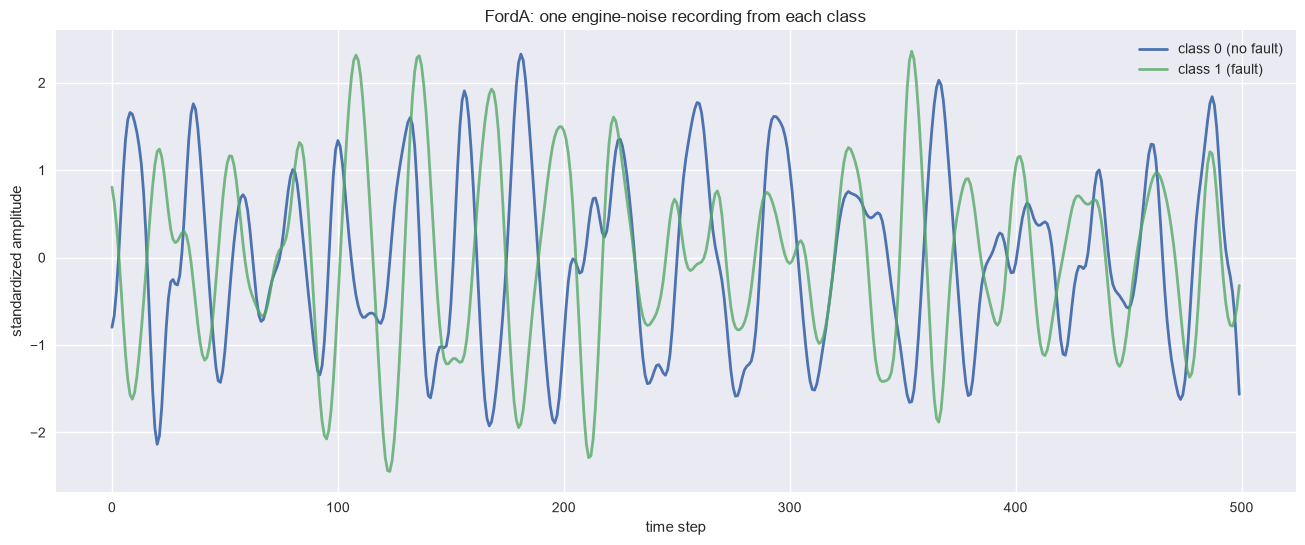

In [10]:
# one example of each class, drawn from the training set
example_0 = X_train[y_train == 0][0, :, 0]
example_1 = X_train[y_train == 1][0, :, 0]

plt.plot(example_0, linewidth=2, label='class 0 (no fault)')
plt.plot(example_1, linewidth=2, alpha=0.8, label='class 1 (fault)')
plt.title('FordA: one engine-noise recording from each class')
plt.xlabel('time step')
plt.ylabel('standardized amplitude')
plt.legend()
plt.show()

This code selects and plots example time series data from the training set, one for each class (0 and 1).

It first extracts a single example of class 0 (`example_0`) by filtering `X_train` to include only samples where `y_train` is equal to 0, then selecting the first sample (`[0, :, 0]`). Similarly, it extracts a single example of class 1 (`example_1`). The `[:, 0]` indexing selects all time steps and the first channel.

Then, it uses Matplotlib to create a plot showing both examples. It plots `example_0` with a solid line (linewidth=2) labeled "class 0 (no fault)" and `example_1` with a slightly transparent line (alpha=0.8) labeled "class 1 (fault)". The plot is titled "FordA: one engine-noise recording from each class", and the axes are labeled appropriately ("time step" and "standardized amplitude"). A legend is added to identify the classes, and finally, `plt.show()` displays the plot. This visualization allows for a quick inspection of the data and helps understand the differences between the two classes.

In [11]:
# hide 95% of the training labels
mask_lab = make_labeled_split(y_train, CFG.label_fraction, CFG.SEED)

X_lab, y_lab = X_train[mask_lab], y_train[mask_lab]     # the 5% we may use
X_unlab = X_train[~mask_lab]                            # the 95% without labels
y_unlab_secret = y_train[~mask_lab]                     # kept ONLY to audit pseudo-labels

print(f'labeled subset:   {X_lab.shape[0]} series, class counts {np.bincount(y_lab)}')
print(f'unlabeled pool:   {X_unlab.shape[0]} series')

labeled subset:   180 series, class counts [90 90]
unlabeled pool:   3421 series


This code creates a labeled and an unlabeled subset from the training data, simulating a semi-supervised learning scenario.

It calls the `make_labeled_split` function to generate a boolean mask (`mask_lab`) that indicates which samples in the training set will be kept as labeled data. The fraction of labels to keep is determined by `CFG.label_fraction`, and reproducibility is ensured using `CFG.SEED`.

The code then uses this mask to split the training data into two subsets: `X_lab` and `y_lab` contain the labeled samples, while `X_unlab` contains the unlabeled samples. The original labels for the unlabeled subset are stored in `y_unlab_secret`, but these will only be used later for evaluating the quality of pseudo-labels generated by the model – they won’t be directly used during training.

Finally, it prints information about both subsets: the number of series in the labeled subset and their class counts (using `np.bincount`), as well as the number of series in the unlabeled pool. This provides an overview of the size and composition of each dataset.

# Baselines: how far do labels alone take us?

In [12]:
# 1-nearest-neighbour on the raw series - the classic baseline of the field
knn_full = KNeighborsClassifier(n_neighbors=1).fit(X_train[..., 0], y_train)
acc = float(knn_full.score(X_test[..., 0], y_test))
scores['1-NN (100% labels)'] = acc
print(f'1-NN, all labels:      {acc:.3f}')

knn_small = KNeighborsClassifier(n_neighbors=1).fit(X_lab[..., 0], y_lab)
acc = float(knn_small.score(X_test[..., 0], y_test))
scores['1-NN (5% labels)'] = acc
print(f'1-NN, 5% of labels:    {acc:.3f}')

1-NN, all labels:      0.665
1-NN, 5% of labels:    0.585


This code establishes a baseline performance using a 1-nearest neighbor (1-NN) classifier on both the full labeled training set and the small labeled subset created earlier.

First, it trains a 1-NN classifier (`knn_full`) using all available training data (`X_train` and `y_train`). The `[..., 0]` indexing selects only the first channel of the time series data for use as features. It then calculates the accuracy of this model on the test set (`X_test` and `y_test`) using the `score` method, converts it to a float, stores it in the `scores` dictionary with the key '1-NN (100% labels)', and prints the result formatted to three decimal places.

Next, it trains another 1-NN classifier (`knn_small`) but this time using only the small labeled subset (`X_lab` and `y_lab`). It then evaluates its accuracy on the test set in the same way as before, stores the score in the `scores` dictionary with the key '1-NN (5% labels)', and prints the result.

This comparison provides a baseline to assess how much improvement can be achieved by more sophisticated models or semi-supervised learning techniques. It demonstrates the performance achievable when using all available labeled data versus only a small fraction of it.

In [13]:
# the supervised ceiling: our CNN trained on ALL 3601 labels
model_full = fit_classifier(X_train, y_train, CFG.sup_epochs, CFG.batch_size)
acc = test_accuracy(model_full, 'supervised CNN (100% labels)')
print(f'supervised CNN, all labels: {acc:.3f}')

supervised CNN, all labels: 0.932


This code trains a convolutional neural network (CNN) on the full labeled training dataset and evaluates its performance.

It calls the `fit_classifier` function to train a classifier model using the entire training set (`X_train`, `y_train`), along with hyperparameters defined in the `CFG` object, specifically `sup_epochs` for the number of training epochs and `batch_size`. The resulting trained model is stored in the variable `model_full`.

Then, it calls the `test_accuracy` function to evaluate the performance of `model_full` on the test dataset (`X_test`, `y_test`). The accuracy score is recorded in the `scores` dictionary with the key 'supervised CNN (100% labels)', and the result is printed to the console, formatted to three decimal places.

This step establishes a "supervised ceiling" – the best possible performance achievable by training a model using only the labeled data without any semi-supervised techniques. It serves as a benchmark for evaluating the effectiveness of methods that leverage unlabeled data.

In [14]:
# the label-scarce reality: the SAME architecture, but only 180 labels
model_small = fit_classifier(X_lab, y_lab, CFG.small_epochs, CFG.small_batch)
acc = test_accuracy(model_small, 'supervised CNN (5% labels)')
print(f'supervised CNN, 5% of labels: {acc:.3f}')

supervised CNN, 5% of labels: 0.799


This code trains the same CNN architecture as before, but this time using only the small labeled subset of the data and evaluates its performance.

It calls the `fit_classifier` function to train a classifier model using the limited labeled dataset (`X_lab`, `y_lab`). It uses hyperparameters specified in the `CFG` object for training on the small labeled set: `small_epochs` determines the number of epochs, and `small_batch` sets the batch size. The trained model is stored in the variable `model_small`.

Next, it calls the `test_accuracy` function to evaluate the performance of `model_small` on the test dataset (`X_test`, `y_test`). The resulting accuracy score is recorded in the `scores` dictionary with the key 'supervised CNN (5% labels)', and printed to the console formatted to three decimal places.

This step demonstrates the significant drop in performance that occurs when training a model with only a small fraction of labeled data, highlighting the need for techniques like semi-supervised learning to effectively utilize unlabeled data.

# Self-supervised learning

## Pretext task 1: masked reconstruction

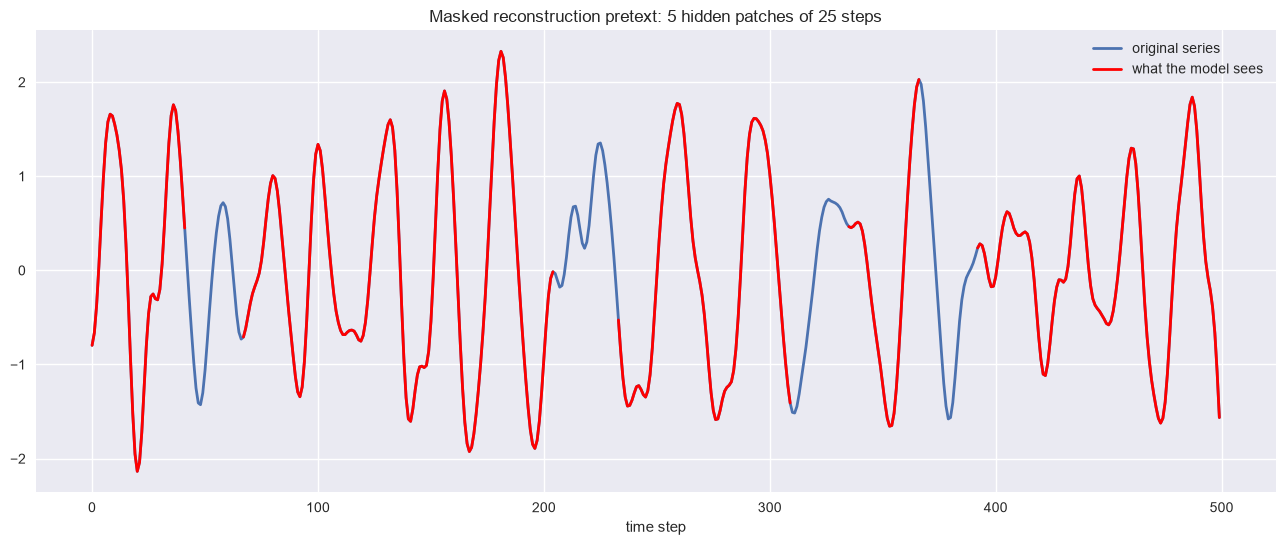

In [15]:
PATCH_LEN = 25    # length of each hidden stretch
N_PATCHES = 5     # stretches hidden per series (~25% of all 500 steps)

# demonstrate the pretext task on one training series
rng_demo = np.random.default_rng(CFG.SEED)
demo_masked, demo_mask = mask_patches(X_train[:1], rng_demo,
                                      patch_len=PATCH_LEN, n_patches=N_PATCHES)

plt.plot(X_train[0, :, 0], linewidth=2, label='original series')
plt.plot(np.where(demo_mask[0, :, 0], np.nan, demo_masked[0, :, 0]),
         color='red', linewidth=2, label='what the model sees')
plt.title(f'Masked reconstruction pretext: {N_PATCHES} hidden patches of {PATCH_LEN} steps')
plt.xlabel('time step')
plt.legend()
plt.show()

This code demonstrates the masking strategy used for a self-supervised pretext task, specifically masked reconstruction.

It first defines `PATCH_LEN` as 25, representing the length of each contiguous stretch to be masked, and `N_PATCHES` as 5, indicating the number of such stretches to hide per time series (approximately 25% of the total 500 steps).

Then, it initializes a random number generator (`rng_demo`) using the seed specified in `CFG.SEED`. It calls the `mask_patches` function with the first training sample (`X_train[:1]`), the random number generator, and the defined patch length and number of patches to create a masked version of the data (`demo_masked`) and its corresponding mask (`demo_mask`).

Finally, it generates a plot to visualize the masking process. It plots the original time series using a solid blue line labeled "original series". The masked series is plotted in red, but with `np.nan` (Not a Number) values inserted at the positions where the mask is True – effectively creating gaps in the plot corresponding to the hidden patches. This visualization helps understand what information the model will be trained to reconstruct during the pretext task. The plot includes a title explaining the masking strategy and labels for the axes.

In [16]:
# encoder (time axis preserved) + a per-timestep linear head = masked autoencoder
keras.utils.set_random_seed(CFG.SEED)
rng_mask = np.random.default_rng(CFG.SEED)

with keras.device(DEVICE):
    encoder_masked = build_encoder(pooled=False)
    inp = keras.Input(shape=(SEQ_LEN, 1))
    h = encoder_masked(inp)
    out = layers.Dense(1)(h)          # one reconstructed value per time step
    masked_ae = keras.Model(inp, out)
    masked_ae.compile(optimizer='adam', loss='mse')

    X_masked, M_train = mask_patches(X_train, rng_mask,
                                     patch_len=PATCH_LEN, n_patches=N_PATCHES)
    # sample_weight = the mask -> the loss is scored ONLY where the holes are
    history = masked_ae.fit(X_masked, X_train,
                            sample_weight=M_train[..., 0].astype('float32'),
                            epochs=CFG.pretrain_epochs,
                            batch_size=CFG.batch_size, verbose=0)

# Keras averages the weighted loss over ALL positions, so divide by the mask
# fraction to recover the mean squared error per hidden step
mask_frac = float(M_train[..., 0].mean())
print(f'reconstruction MSE at hidden steps after pretraining: '
      f'{history.history["loss"][-1] / mask_frac:.4f}')

reconstruction MSE at hidden steps after pretraining: 0.3358


This code implements a masked autoencoder (MAE) for self-supervised pretraining of the encoder network.

It starts by building an encoder (`encoder_masked`) using `build_encoder` with `pooled=False`, which means the encoder preserves the time axis in its output. It then defines a Keras model (`masked_ae`) that takes a time series as input, passes it through the encoder, and uses a dense layer to reconstruct the original signal at each time step. The model is compiled using the Adam optimizer and mean squared error (MSE) loss function.

Next, it generates masked versions of the training data (`X_masked`) and corresponding masks (`M_train`) using the `mask_patches` function with the specified patch length and number of patches. Crucially, the mask is used as a sample weight during training – this ensures that the loss is only calculated for the masked portions of the input, forcing the model to learn to reconstruct the hidden segments.

The MAE is then trained using `fit`, passing in the masked data (`X_masked`), the original data (`X_train`) as the target, and the mask as sample weights. The training runs for a number of epochs specified by `CFG.pretrain_epochs` with a batch size defined by `CFG.batch_size`. Verbosity is set to 0 to suppress output during training.

Finally, it calculates and prints the reconstruction MSE at the masked steps after pretraining. Because Keras averages the weighted loss over all positions (including unmasked ones), the final loss value is divided by the fraction of masked elements (`mask_frac`) to obtain a more meaningful estimate of the average squared error specifically for the reconstructed patches. This provides an indication of how well the model has learned to reconstruct the missing parts of the input time series.

MSE at hidden positions only (test set): 0.386


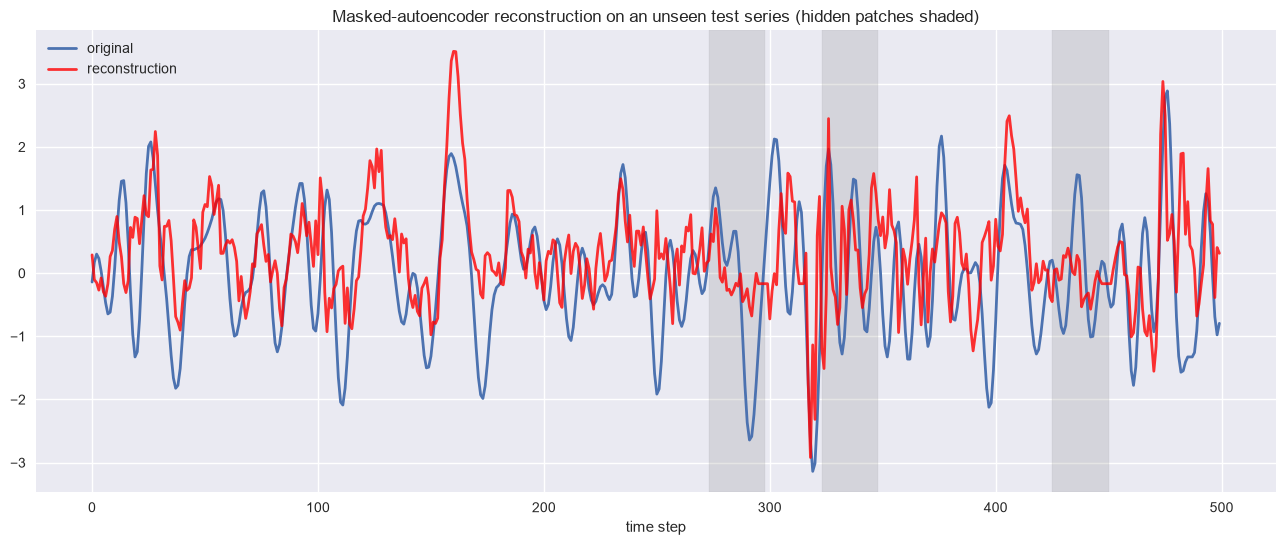

In [17]:
# how well does it fill the holes? (on TEST series it never saw)
rng_recon = np.random.default_rng(7)
X_test_masked, test_mask = mask_patches(X_test, rng_recon,
                                        patch_len=PATCH_LEN, n_patches=N_PATCHES)
recon = masked_ae.predict(X_test_masked, batch_size=256, verbose=0)

mse_hidden = float(np.mean((recon[test_mask] - X_test[test_mask]) ** 2))
print(f'MSE at hidden positions only (test set): {mse_hidden:.3f}')

SHOW = 0   # which test series to display
plt.plot(X_test[SHOW, :, 0], linewidth=2, label='original')
plt.plot(recon[SHOW, :, 0], color='red', linewidth=2, alpha=0.8, label='reconstruction')
for s in np.where(np.diff(test_mask[SHOW, :, 0].astype(int)) == 1)[0]:
    plt.axvspan(s, s + PATCH_LEN, color='gray', alpha=0.2)
plt.title('Masked-autoencoder reconstruction on an unseen test series (hidden patches shaded)')
plt.xlabel('time step')
plt.legend()
plt.show()

This code evaluates the performance of the pre-trained masked autoencoder on the held-out test set, specifically focusing on its ability to reconstruct masked portions of the signal.

It first generates masked versions of the test data (`X_test_masked`) and corresponding masks (`test_mask`) using `mask_patches` with a new random number generator (`rng_recon`). Then, it uses the trained MAE (`masked_ae`) to predict the reconstructed signals (`recon`) from the masked test data.

Next, it calculates the mean squared error (MSE) specifically at the hidden positions in the test set by comparing the reconstructed values (`recon[test_mask]`) with the original values (`X_test[test_mask]`). The calculated MSE is printed to the console formatted to three decimal places. This provides a quantitative measure of how well the model can reconstruct the masked portions of unseen data.

Finally, it generates a plot visualizing the reconstruction for a single test series (specified by `SHOW`). It plots the original time series and the reconstructed time series on the same graph. The hidden patches are highlighted using shaded gray regions (`axvspan`), allowing for a visual assessment of the reconstruction quality in those areas. The plot includes a title, axis labels, and a legend to aid interpretation.

In [18]:
def linear_probe(encoder, name=None):
    """Freeze the encoder; train only a logistic regression on the 180 labels."""
    with keras.device(DEVICE):
        f_lab = encoder.predict(X_lab, batch_size=256, verbose=0)
        f_test = encoder.predict(X_test, batch_size=256, verbose=0)
    if f_lab.ndim == 3:                       # sequence output -> average over time
        f_lab, f_test = f_lab.mean(axis=1), f_test.mean(axis=1)
    clf = LogisticRegression(max_iter=2000).fit(f_lab, y_lab)
    acc = float(clf.score(f_test, y_test))
    if name is not None:
        scores[name] = acc
    return acc

acc = linear_probe(encoder_masked, 'masked AE + linear probe (5%)')
print(f'masked AE, linear probe on 5% labels: {acc:.3f}')

masked AE, linear probe on 5% labels: 0.782


This code performs a linear probing evaluation of the pre-trained encoder. Linear probing involves freezing the weights of the encoder and training a simple linear classifier (logistic regression) on top of the encoded features to assess the quality of those features.

It first defines a function called `linear_probe` that takes the encoder model as input, along with an optional name for recording the score. Inside the function, it uses the encoder to extract feature representations from both the labeled training data (`X_lab`) and the test data (`X_test`). The `predict` method is used with a batch size of 256 and verbosity set to 0.

If the encoder outputs a sequence (i.e., has three dimensions), it averages the features over the time axis using `.mean(axis=1)` to obtain a single feature vector per sample. This is necessary if the encoder was not pooled during its initial construction.

Then, it trains a logistic regression classifier (`LogisticRegression`) on the extracted labeled training features (`f_lab`) and corresponding labels (`y_lab`). The `max_iter` parameter is set to 2000 to allow for sufficient iterations during training.

The accuracy of the trained classifier is evaluated on the test data (`f_test`, `y_test`) using the `score` method, converted to a float, and stored in the `scores` dictionary with the provided name if one is given. The function returns the calculated accuracy.

Finally, it calls the `linear_probe` function with the pre-trained masked autoencoder (`encoder_masked`) as input, providing the name 'masked AE + linear probe (5%)'. The resulting accuracy score is printed to the console formatted to three decimal places. This provides a measure of how well the features learned by the masked autoencoder generalize to a downstream classification task when combined with a simple linear classifier.

In [19]:
# fine-tuning: same pretrained encoder, but ALL weights may adapt (small lr)
model_ft = fit_classifier(X_lab, y_lab, CFG.finetune_epochs, CFG.small_batch,
                          encoder=copy_encoder(encoder_masked, pooled=False),
                          lr=1e-4)
acc = test_accuracy(model_ft, 'masked AE + fine-tune (5%)')
print(f'masked AE, fine-tuned on 5% labels: {acc:.3f}')

masked AE, fine-tuned on 5% labels: 0.889


This code performs fine-tuning of the pre-trained masked autoencoder. Fine-tuning involves unfreezing all weights in the network and continuing training on the labeled data with a smaller learning rate to adapt the learned features specifically to the classification task.

It calls the `fit_classifier` function to train a classifier model using the small labeled dataset (`X_lab`, `y_lab`). It uses hyperparameters defined in the `CFG` object for fine-tuning: `finetune_epochs` specifies the number of epochs, and `small_batch` sets the batch size.

Crucially, it passes a *copy* of the pre-trained encoder (`encoder_masked`) to the `fit_classifier` function using `copy_encoder(encoder_masked, pooled=False)`. This ensures that the original weights of the masked autoencoder are preserved and can be used for further experiments. The `pooled=False` argument ensures that the copied encoder retains the time axis in its output.

A smaller learning rate (`lr=1e-4`) is used during fine-tuning to avoid disrupting the pre-trained weights too much. 

The resulting trained model is stored in the variable `model_ft`. The performance of the fine-tuned model is then evaluated on the test dataset using the `test_accuracy` function, and the accuracy score is printed to the console formatted to three decimal places. This demonstrates how much improvement can be achieved by adapting the pre-trained features specifically to the classification task through fine-tuning.

In [20]:
# the control experiment: pretrain with POINTWISE masking instead of patches
keras.utils.set_random_seed(CFG.SEED)
rng_mask_pt = np.random.default_rng(CFG.SEED)

with keras.device(DEVICE):
    encoder_pointwise = build_encoder(pooled=False)
    inp = keras.Input(shape=(SEQ_LEN, 1))
    out = layers.Dense(1)(encoder_pointwise(inp))
    pointwise_ae = keras.Model(inp, out)
    pointwise_ae.compile(optimizer='adam', loss='mse')
    X_masked_pt, M_pt = mask_patches(X_train, rng_mask_pt, pointwise=True)
    pointwise_ae.fit(X_masked_pt, X_train,
                     sample_weight=M_pt[..., 0].astype('float32'),
                     epochs=CFG.pretrain_epochs, batch_size=CFG.batch_size, verbose=0)

print(f'patch masking hides {M_train.mean():.1%} of all time steps, '
      f'pointwise masking {M_pt.mean():.1%}')

acc = linear_probe(encoder_pointwise, 'pointwise-mask AE + probe (5%)')
print(f'pointwise masking, linear probe: {acc:.3f}')

patch masking hides 22.5% of all time steps, pointwise masking 25.0%
pointwise masking, linear probe: 0.742


This code repeats the pretraining and linear probing process, but this time using a different masking strategy – pointwise masking instead of patch masking. This serves as a control experiment to compare the effectiveness of the two approaches.

It starts by building an encoder (`encoder_pointwise`) with the same architecture as before (time axis preserved). It then defines a masked autoencoder (`pointwise_ae`) using this encoder and compiles it with the Adam optimizer and MSE loss function.

Next, it generates masked data (`X_masked_pt`) and corresponding masks (`M_pt`) using `mask_patches` with the `pointwise=True` argument, which randomly hides individual time steps instead of contiguous patches. The MAE is then trained on this pointwise-masked data, using the mask as sample weights to focus the learning on the hidden portions of the input.

It prints the fraction of masked elements for both patch masking (using `M_train`) and pointwise masking (using `M_pt`), allowing a comparison of the amount of information hidden in each case.

Finally, it performs linear probing using the trained `encoder_pointwise` to evaluate the quality of the learned features. The resulting accuracy is printed to the console, providing a measure of how well this approach generalizes to the classification task. This allows for a direct comparison between the performance achieved with patch masking and pointwise masking.

## Pretext task 2: contrastive learning

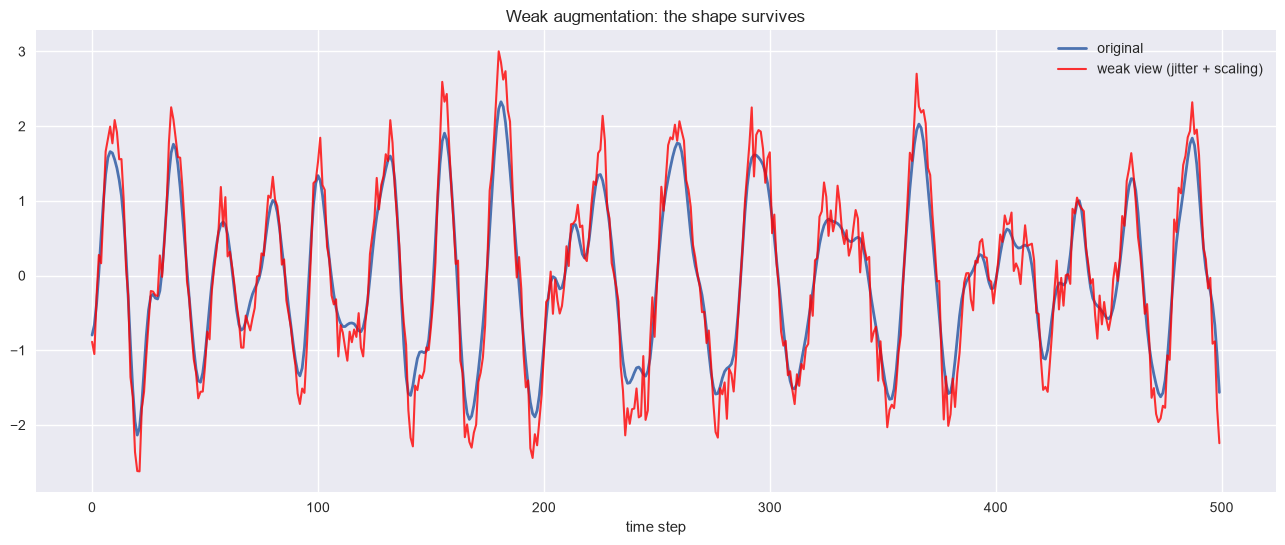

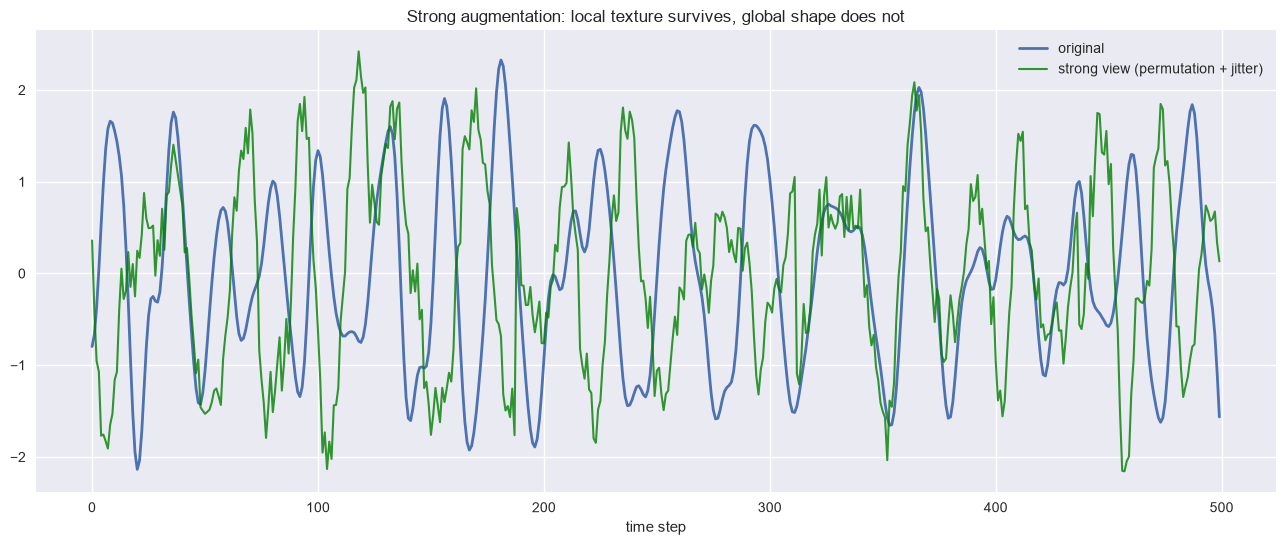

In [21]:
# what the two augmentation strengths do to a series
rng_views = np.random.default_rng(CFG.SEED)
series = X_train[:1]

plt.plot(series[0, :, 0], linewidth=2, label='original')
plt.plot(weak_aug(series, rng_views)[0, :, 0], color='red', linewidth=1.5,
         alpha=0.8, label='weak view (jitter + scaling)')
plt.title('Weak augmentation: the shape survives')
plt.xlabel('time step')
plt.legend()
plt.show()

plt.plot(series[0, :, 0], linewidth=2, label='original')
plt.plot(strong_aug(series, rng_views)[0, :, 0], color='green', linewidth=1.5,
         alpha=0.8, label='strong view (permutation + jitter)')
plt.title('Strong augmentation: local texture survives, global shape does not')
plt.xlabel('time step')
plt.legend()
plt.show()

This code visualizes the effect of the weak and strong data augmentations defined earlier on a single time series from the training set.

It initializes a random number generator (`rng_views`) using the seed specified in `CFG.SEED`. It then selects the first time series from the training data (`X_train[:1]`) and stores it in the variable `series`.

The code generates two plots. The first plot shows the original time series alongside its weakly augmented version, created by applying the `weak_aug` function (jitter + scaling). The title indicates that weak augmentation preserves the overall shape of the signal.

The second plot displays the original time series and its strongly augmented counterpart, generated using the `strong_aug` function (permutation + jitter). The title highlights that strong augmentation disrupts the global temporal structure but preserves local texture or patterns within segments of the signal.

Both plots include a legend to identify the different lines and axis labels for clarity. These visualizations help understand how each type of augmentation alters the data, which is important for understanding their impact on model training and generalization.

In [22]:
def nt_xent_loss(temperature=0.1):
    """NT-Xent (InfoNCE) contrastive loss.

    y_pred carries the two views' projections side by side: [z1 | z2], (B, 2D).
    Views of the same series are positives; everything else in the batch is negative.
    """
    def loss(y_true, y_pred):
        d = ops.shape(y_pred)[-1] // 2
        z1 = ops.normalize(y_pred[:, :d], axis=-1)
        z2 = ops.normalize(y_pred[:, d:], axis=-1)
        z = ops.concatenate([z1, z2], axis=0)                 # (2B, D)
        sim = ops.matmul(z, ops.transpose(z)) / temperature   # (2B, 2B) similarities
        b = ops.shape(z1)[0]
        n = 2 * b
        sim = sim - ops.eye(n) * 1e9                          # forbid matching yourself
        positive_idx = ops.concatenate([ops.arange(b, n), ops.arange(0, b)], axis=0)
        return ops.categorical_crossentropy(ops.one_hot(positive_idx, n),
                                            sim, from_logits=True)
    return loss

This code defines a function that implements the Normalized Temperature-scaled Cross Entropy (NT-Xent) loss, also known as InfoNCE contrastive loss. This loss is commonly used in self-supervised learning to encourage representations of different views of the same data point to be similar while being dissimilar from other data points.

The outer function `nt_xent_loss(temperature=0.1)` takes a temperature parameter as input, which controls the sharpness of the similarity distribution. It returns an inner function called `loss` that calculates the actual loss given true and predicted values.

Inside the `loss` function:
- `d = ops.shape(y_pred)[-1] // 2`: This line determines the dimension of each view's projection by dividing the last dimension of the input tensor `y_pred` by 2. It assumes that `y_pred` contains projections from two different views concatenated side by side.
- `z1 = ops.normalize(y_pred[:, :d], axis=-1)` and `z2 = ops.normalize(y_pred[:, d:], axis=-1)`: These lines extract the projections for the first view (`z1`) and the second view (`z2`) from `y_pred` and normalize them along the last axis (axis=-1) to unit length. Normalization is crucial for contrastive learning as it ensures that similarity scores are based on direction rather than magnitude.
- `z = ops.concatenate([z1, z2], axis=0)`: This line concatenates the normalized projections of both views along the first axis (axis=0), creating a tensor `z` with shape (2B, D), where B is the batch size and D is the projection dimension.
- `sim = ops.matmul(z, ops.transpose(z)) / temperature`: This line calculates the similarity matrix between all pairs of projections in `z`. It performs a matrix multiplication between `z` and its transpose, then divides the result by the temperature parameter to scale the similarities.
- `b = ops.shape(z1)[0]` and `n = 2 * b`: These lines determine the batch size (b) and the total number of samples in the similarity matrix (n).
- `sim = sim - ops.eye(n) * 1e9`: This line sets the diagonal elements of the similarity matrix to a very large negative value (-1e9) to prevent each sample from being considered similar to itself.
- `positive_idx = ops.concatenate([ops.arange(b, n), ops.arange(0, b)], axis=0)`: This line creates an index tensor `positive_idx` that identifies the pairs of samples representing positive matches (i.e., different views of the same data point). It concatenates two ranges: one from b to n (representing the second view) and another from 0 to b (representing the first view).
- `return ops.categorical_crossentropy(ops.one_hot(positive_idx, n), sim, from_logits=True)`: This line calculates the categorical cross-entropy loss between the predicted similarities (`sim`) and the one-hot encoded positive indices (`ops.one_hot(positive_idx, n)`). The `from_logits=True` argument indicates that the input similarities are not probabilities but rather logits (unnormalized scores).

In essence, this loss function encourages the model to learn representations where different views of the same data point have high similarity while being dissimilar from other data points in the batch.

In [23]:
# siamese pretraining: two augmented views through ONE shared encoder
keras.utils.set_random_seed(CFG.SEED)
rng_con = np.random.default_rng(CFG.SEED)

with keras.device(DEVICE):
    encoder_con = build_encoder(pooled=True)
    projection = keras.Sequential([layers.Dense(64, activation='relu'),
                                   layers.Dense(32)])
    view_a = keras.Input(shape=(SEQ_LEN, 1))
    view_b = keras.Input(shape=(SEQ_LEN, 1))
    z_a = projection(encoder_con(view_a))
    z_b = projection(encoder_con(view_b))
    contrastive_model = keras.Model([view_a, view_b],
                                    ops.concatenate([z_a, z_b], axis=-1))
    contrastive_model.compile(optimizer='adam', loss=nt_xent_loss())

    dummy_target = np.zeros(len(X_train))       # NT-Xent ignores y_true entirely
    for epoch in range(CFG.pretrain_epochs):
        V1 = weak_aug(X_train, rng_con)         # fresh random views EVERY epoch
        V2 = weak_aug(X_train, rng_con)
        contrastive_model.fit([V1, V2], dummy_target, epochs=1,
                              batch_size=CFG.batch_size, verbose=0)

contrastive_weights = encoder_con.get_weights()   # snapshot for later reuse
print('contrastive pretraining finished')

contrastive pretraining finished


This code implements a contrastive learning approach to pretrain the encoder network using the NT-Xent loss.

It starts by building an encoder (`encoder_con`) with pooling enabled (pooled=True). A projection head consisting of two dense layers with ReLU activation is added on top of the encoder to map the encoded features into a lower-dimensional space suitable for contrastive learning.

Two input layers, `view_a` and `view_b`, are defined to represent the two different views of the same data point. Both inputs are passed through the encoder and then through the projection head to obtain their respective projections (`z_a` and `z_b`). The outputs of both branches are concatenated along the last axis using `ops.concatenate`.

A Keras model (`contrastive_model`) is created that takes two inputs (view_a and view_b) and outputs the concatenated projections. This model is compiled with the Adam optimizer and the NT-Xent loss function defined earlier.

Since the NT-Xent loss doesn't require true labels, a dummy target array (`dummy_target`) filled with zeros is created. The code then iterates for `CFG.pretrain_epochs`. In each epoch:
- Two sets of augmented views (`V1` and `V2`) are generated from the training data using the `weak_aug` function (jitter + scaling). Importantly, fresh random augmentations are created *every* epoch to ensure diversity.
- The contrastive model is trained on these two sets of augmented views, with the dummy target array as input.

Finally, the weights of the encoder (`encoder_con`) are saved in `contrastive_weights` for later reuse (e.g., fine-tuning). A message indicating that contrastive pretraining has finished is printed to the console. This process learns a representation where different augmented views of the same data point are close together in the embedding space, while being distant from other data points.

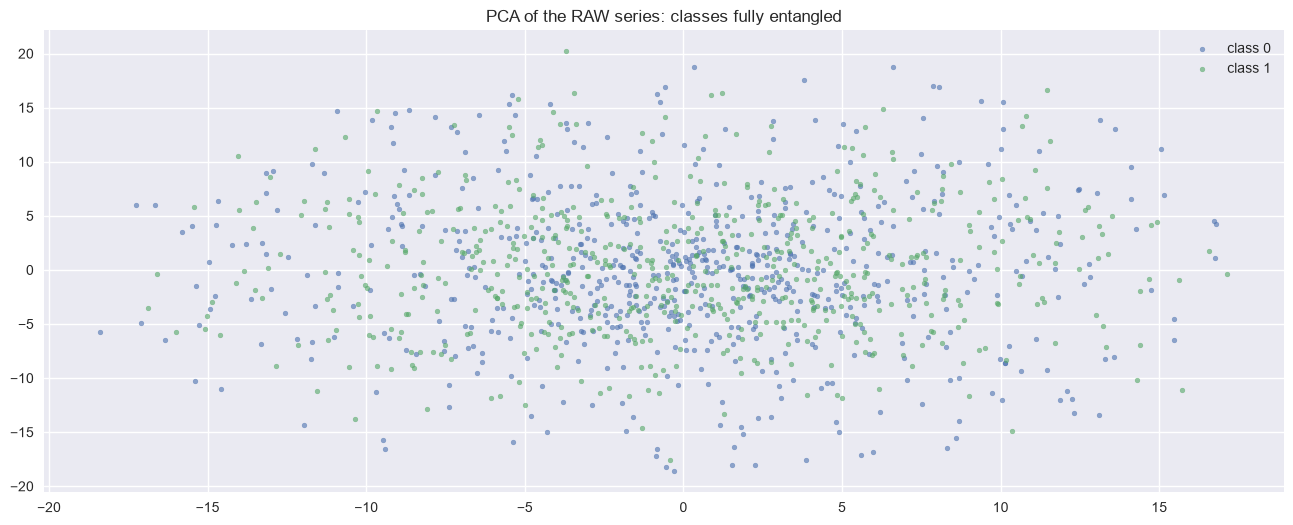

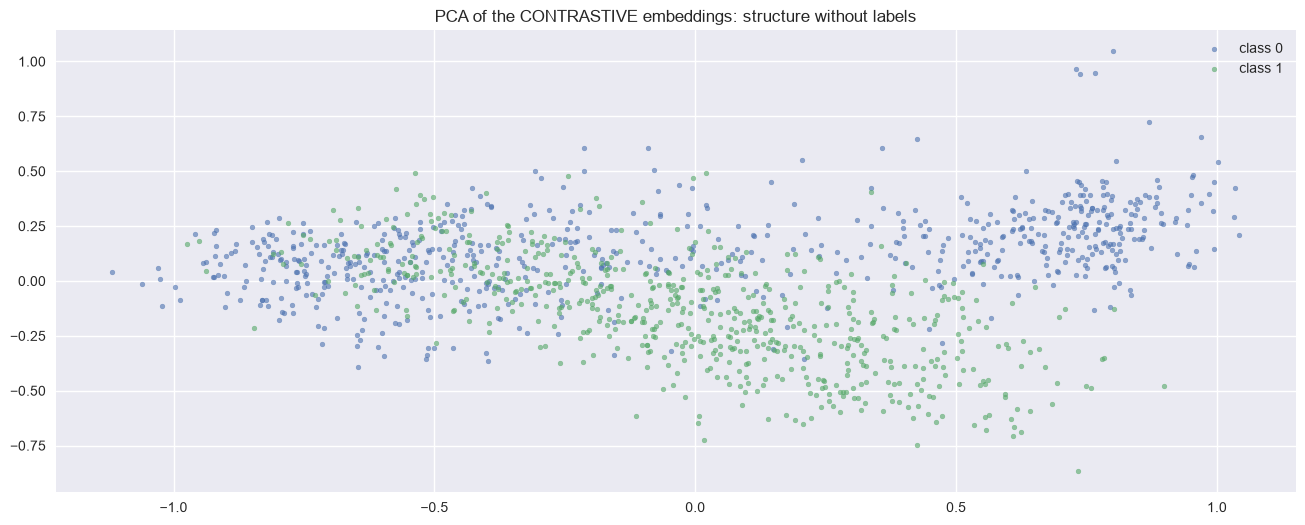

In [24]:
# what did it learn? PCA of the TEST-set embeddings, colored by the TRUE labels
with keras.device(DEVICE):
    emb_test = encoder_con.predict(X_test, batch_size=256, verbose=0)

flat_2d = PCA(n_components=2).fit_transform(X_test[..., 0])   # raw series, for contrast
emb_2d = PCA(n_components=2).fit_transform(emb_test)

plt.scatter(flat_2d[y_test == 0, 0], flat_2d[y_test == 0, 1], s=12, alpha=0.6, label='class 0')
plt.scatter(flat_2d[y_test == 1, 0], flat_2d[y_test == 1, 1], s=12, alpha=0.6, label='class 1')
plt.title('PCA of the RAW series: classes fully entangled')
plt.legend()
plt.show()

plt.scatter(emb_2d[y_test == 0, 0], emb_2d[y_test == 0, 1], s=12, alpha=0.6, label='class 0')
plt.scatter(emb_2d[y_test == 1, 0], emb_2d[y_test == 1, 1], s=12, alpha=0.6, label='class 1')
plt.title('PCA of the CONTRASTIVE embeddings: structure without labels')
plt.legend()
plt.show()

This code visualizes the learned representations from the contrastively pre-trained encoder using Principal Component Analysis (PCA). It compares the PCA projections of the raw time series data with those of the encoded features to demonstrate the effectiveness of the pretraining process.

First, it uses the pretrained `encoder_con` to generate embeddings for the test dataset (`X_test`). The resulting embeddings are stored in `emb_test`.

Then, it applies PCA to both the raw time series data (`X_test[..., 0]`) and the learned embeddings (`emb_test`), reducing their dimensionality to two components. The results are stored in `flat_2d` (for the raw data) and `emb_2d` (for the embeddings).

Two scatter plots are generated:
- The first plot shows the PCA projection of the raw time series data, colored by the true labels (`y_test`). The title indicates that the classes are fully entangled in this space, meaning there is no clear separation between them.
- The second plot displays the PCA projection of the contrastively learned embeddings, also colored by the true labels. The title suggests that the embeddings exhibit structure even without explicit label information, indicating that the pretraining process has successfully captured meaningful features that separate the classes.

These visualizations demonstrate how the contrastive learning objective has transformed the data into a more structured representation where different classes are better separated in the embedding space compared to the raw time series data. This improved separation is crucial for downstream classification tasks.

In [25]:
# the same two exams as before: linear probe, then fine-tune
acc = linear_probe(encoder_con, 'contrastive + linear probe (5%)')
print(f'contrastive, linear probe on 5% labels: {acc:.3f}')

model_con_ft = fit_classifier(X_lab, y_lab, CFG.finetune_epochs, CFG.small_batch,
                              encoder=copy_encoder(encoder_con), lr=1e-4)
acc = test_accuracy(model_con_ft, 'contrastive + fine-tune (5%)')
print(f'contrastive, fine-tuned on 5% labels: {acc:.3f}')

contrastive, linear probe on 5% labels: 0.913
contrastive, fine-tuned on 5% labels: 0.923


This code evaluates the performance of the contrastively pre-trained encoder by performing linear probing and fine-tuning, similar to what was done with the masked autoencoder.

First, it calls the `linear_probe` function with the pretrained `encoder_con` as input, recording the accuracy in the `scores` dictionary under the key 'contrastive + linear probe (5%)'. The resulting accuracy is printed to the console formatted to three decimal places. This assesses how well the learned representations generalize to a classification task using only a simple linear classifier on top of the encoder.

Next, it fine-tunes the contrastively pretrained encoder by calling the `fit_classifier` function with the small labeled dataset (`X_lab`, `y_lab`). A copy of the encoder is created using `copy_encoder(encoder_con)` to avoid modifying the original weights. The training process uses a learning rate of 1e-4 and runs for `CFG.finetune_epochs` epochs with a batch size of `CFG.small_batch`.

Finally, it evaluates the performance of the fine-tuned model on the test dataset using the `test_accuracy` function, recording the accuracy in the `scores` dictionary under the key 'contrastive + fine-tune (5%)'. The resulting accuracy is printed to the console formatted to three decimal places. This demonstrates how much improvement can be achieved by adapting the pretrained features specifically to the classification task through fine-tuning.

By comparing the results of linear probing and fine-tuning, as well as comparing the contrastive pretraining approach with the masked autoencoder approach, this code provides a comprehensive evaluation of different self-supervised learning strategies for this dataset.

# Semi-supervised learning


## Pseudo-labeling (self-training)

In [26]:
# the weak model from the baseline section labels the pool it was never trained on
pool_probs = model_small.predict(X_unlab, batch_size=256, verbose=0)
pool_conf = pool_probs.max(axis=1)          # confidence = probability of the argmax class
pseudo_labels = pool_probs.argmax(axis=1)

accepted = pool_conf >= CFG.conf_threshold
audit_acc = float((pseudo_labels[accepted] == y_unlab_secret[accepted]).mean())

print(f'pool size {len(X_unlab)}, accepted at conf>={CFG.conf_threshold}: {accepted.sum()}')
print(f'class balance of accepted pseudo-labels: {np.bincount(pseudo_labels[accepted])}')
print(f'audit: accepted pseudo-labels are {audit_acc:.1%} correct '
      f'(vs {float((pseudo_labels == y_unlab_secret).mean()):.1%} for ALL pseudo-labels)')

pool size 3421, accepted at conf>=0.95: 1788
class balance of accepted pseudo-labels: [ 701 1087]
audit: accepted pseudo-labels are 97.5% correct (vs 78.6% for ALL pseudo-labels)


This code implements a self-training step where the model trained on the small labeled subset is used to generate pseudo-labels for the unlabeled data pool. It then evaluates the quality of these pseudo-labels by comparing them to the true labels (which are kept secret during training).

First, it uses the `model_small` (the classifier trained on the 5% labeled dataset) to predict probabilities for each sample in the unlabeled pool (`X_unlab`). The predictions are stored in `pool_probs`.

The confidence score for each prediction is calculated as the maximum probability across all classes using `pool_probs.max(axis=1)`. This represents the model's certainty about its prediction. The predicted class label for each sample is determined by taking the argmax of the probabilities along axis 1, stored in `pseudo_labels`.

A boolean mask `accepted` is created to identify samples where the confidence score exceeds a predefined threshold (`CFG.conf_threshold`). Only these high-confidence pseudo-labels will be considered reliable enough for inclusion in the training set.

The accuracy of the accepted pseudo-labels is evaluated by comparing them to the true labels of the unlabeled pool (`y_unlab_secret`) using `audit_acc`. This provides an estimate of how well the model's predictions align with the ground truth.

Finally, it prints several statistics:
- The size of the unlabeled pool and the number of samples accepted based on the confidence threshold.
- The class balance of the accepted pseudo-labels to ensure that they don’t introduce a significant bias towards one class.
- The audit accuracy (the percentage of correctly labeled samples among those accepted) and the overall accuracy of all generated pseudo-labels, providing a comprehensive assessment of their quality. This allows for an evaluation of how reliable the self-training process is.


In [27]:
STUDENT_EPOCHS = 80   # the combined set is mid-sized: more epochs than full-data
                      # training needs, fewer than the 180-example runs got

# retrain from scratch on real labels + accepted pseudo-labels
X_pseudo = np.concatenate([X_lab, X_unlab[accepted]])
y_pseudo = np.concatenate([y_lab, pseudo_labels[accepted]])

model_pl = fit_classifier(X_pseudo, y_pseudo, STUDENT_EPOCHS, CFG.batch_size)
acc = test_accuracy(model_pl, 'pseudo-labeling (5%)')
print(f'pseudo-labeling, one round: {acc:.3f} (teacher was {scores["supervised CNN (5% labels)"]:.3f})')

pseudo-labeling, one round: 0.892 (teacher was 0.799)


This code retrains the classifier model using a combined dataset consisting of the original labeled data and the high-confidence pseudo-labeled data generated in the previous step.

It defines `STUDENT_EPOCHS` as 80, specifying the number of training epochs for this retraining phase. This value is chosen to be intermediate between the number of epochs used for full-data training and the smaller labeled dataset training.

The original labeled data (`X_lab`, `y_lab`) and the accepted pseudo-labeled data (`X_unlab[accepted]`, `pseudo_labels[accepted]`) are concatenated using `np.concatenate` to create a new combined dataset (`X_pseudo`, `y_pseudo`). This effectively expands the training set with the additional, potentially noisy, labels generated by the model itself.

The `fit_classifier` function is called again to train a new classifier model (`model_pl`) on this expanded dataset using the specified number of epochs and batch size.

Finally, it evaluates the performance of the retrained model on the test dataset using the `test_accuracy` function, recording the accuracy in the `scores` dictionary under the key 'pseudo-labeling (5%)'. The resulting accuracy is printed to the console formatted to three decimal places, along with a comparison to the accuracy achieved by training only on the original 5% labeled data. This allows for an assessment of the effectiveness of the pseudo-labeling strategy in improving model performance.

## Consistency training, FixMatch-style

In [28]:
N_ROUNDS = 3

rng_fix = np.random.default_rng(CFG.SEED)
student = model_small                        # round 1 teacher = the 5%-label baseline
for rnd in range(N_ROUNDS):
    # 1. predict on WEAKLY augmented pool; filter by confidence
    probs = student.predict(weak_aug(X_unlab, rng_fix), batch_size=256, verbose=0)
    conf, pl = probs.max(axis=1), probs.argmax(axis=1)
    keep = conf >= CFG.conf_threshold
    # 2. fresh student: real labels + accepted pool series + their STRONG views
    X_round = np.concatenate([X_lab, X_unlab[keep], strong_aug(X_unlab[keep], rng_fix)])
    y_round = np.concatenate([y_lab, pl[keep], pl[keep]])
    student = fit_classifier(X_round, y_round, STUDENT_EPOCHS, CFG.batch_size)
    audit = float((pl[keep] == y_unlab_secret[keep]).mean()) if keep.sum() else np.nan
    round_acc = test_accuracy(student)
    print(f'round {rnd + 1}: accepted {keep.sum():4d} pseudo-labels '
          f'({audit:.1%} correct), test accuracy {round_acc:.3f}')

scores['FixMatch-style, 3 rounds (5%)'] = round_acc   # the last round's student

round 1: accepted 1320 pseudo-labels (91.9% correct), test accuracy 0.821
round 2: accepted 2721 pseudo-labels (64.3% correct), test accuracy 0.567
round 3: accepted 3375 pseudo-labels (52.0% correct), test accuracy 0.516


This code implements a multi-round self-training loop inspired by the FixMatch algorithm to iteratively improve model performance using pseudo-labeling.

It defines `N_ROUNDS` as 3, specifying the number of iterations in the self-training process. A random number generator (`rng_fix`) is initialized with the seed specified in `CFG.SEED`. The initial teacher model (`student`) is set to `model_small`, which was trained on the original 5% labeled dataset.

The code then enters a loop that repeats for each round:
- **1. Pseudo-labeling:** The current teacher model (`student`) predicts probabilities on weakly augmented versions of the unlabeled data pool (`X_unlab`). Confidence scores and pseudo-labels are extracted from these predictions. Only samples with confidence scores exceeding `CFG.conf_threshold` are accepted, creating a boolean mask `keep`.
- **2. Student Training:** A new student model is trained on an expanded dataset consisting of the original labeled data (`X_lab`, `y_lab`), the accepted pseudo-labeled data (`X_unlab[keep]`, `pl[keep]`), and *strongly* augmented versions of the accepted pseudo-labeled data (`strong_aug(X_unlab[keep], rng_fix)`). The labels for the strongly augmented data are also set to the corresponding pseudo-labels. This is a key aspect of FixMatch, using strong augmentations to improve consistency.
- **3. Evaluation:** The accuracy of the accepted pseudo-labels is audited by comparing them to the true labels (`y_unlab_secret[keep]`). If no samples are accepted in a round (i.e., `keep.sum()` is 0), the audit accuracy is set to NaN. The test accuracy of the newly trained student model is also evaluated using `test_accuracy`.
- **4. Reporting:** The number of accepted pseudo-labels, the audit accuracy, and the test accuracy are printed for each round.

After all rounds have completed, the final student model's test accuracy is stored in the `scores` dictionary under the key 'FixMatch-style, 3 rounds (5%)'. This represents the performance achieved after multiple iterations of self-training with weak and strong augmentations. The code effectively implements a semi-supervised learning pipeline that leverages unlabeled data to improve model generalization.

## Multi-task joint training

In [29]:
LAMBDA_AUX = 0.5    # weight of the auxiliary reconstruction loss

keras.utils.set_random_seed(CFG.SEED)
rng_mt = np.random.default_rng(CFG.SEED)

with keras.device(DEVICE):
    encoder_mt = build_encoder(pooled=False)
    # ONE encoder, two inputs: the classifier reads the clean series, the
    # reconstruction head reads the masked one
    inp_clean = keras.Input(shape=(SEQ_LEN, 1))
    inp_masked = keras.Input(shape=(SEQ_LEN, 1))
    pooled = layers.GlobalAveragePooling1D()(encoder_mt(inp_clean))
    out_cls = layers.Dense(2, activation='softmax', name='cls')(pooled)
    out_rec = layers.Dense(1, name='rec')(encoder_mt(inp_masked))
    multitask = keras.Model([inp_clean, inp_masked],
                            {'cls': out_cls, 'rec': out_rec})
    multitask.compile(optimizer='adam',
                      loss={'cls': 'sparse_categorical_crossentropy', 'rec': 'mse'},
                      loss_weights={'cls': 1.0, 'rec': LAMBDA_AUX})

    # classification loss counts ONLY on labeled rows; reconstruction only in the holes
    y_cls = np.where(mask_lab, y_train, 0)          # dummy 0 where no label exists
    weight_cls = mask_lab.astype(float)             # ...and weight 0 hides the dummies
    X_in, M_mt = mask_patches(X_train, rng_mt,
                              patch_len=PATCH_LEN, n_patches=N_PATCHES)

    multitask.fit([X_train, X_in], {'cls': y_cls, 'rec': X_train},
                  sample_weight={'cls': weight_cls,
                                 'rec': M_mt[..., 0].astype('float32')},
                  epochs=CFG.sup_epochs, batch_size=CFG.batch_size, verbose=0)

    # at inference only the classification branch is needed
    multitask_clf = keras.Model(multitask.inputs[0], out_cls)

pred = np.argmax(multitask_clf.predict(X_test, batch_size=256, verbose=0), axis=1)
scores['multi-task joint (5%)'] = float((pred == y_test).mean())
print(f'multi-task joint training: {scores["multi-task joint (5%)"]:.3f}')

multi-task joint training: 0.865


This code implements a multi-task learning approach where the encoder is trained to simultaneously perform classification and reconstruction, leveraging both labeled and unlabeled data.

It starts by defining `LAMBDA_AUX` as 0.5, which controls the weight of the auxiliary reconstruction loss relative to the classification loss.

An encoder (`encoder_mt`) is built with pooling disabled (pooled=False) to preserve the time axis for the reconstruction task. A multi-task model (`multitask`) is then created with two inputs: `inp_clean` for the clean data used for classification and `inp_masked` for the masked data used for reconstruction. The encoder processes both inputs separately.

The output of the encoder applied to the clean input is pooled using `GlobalAveragePooling1D` and passed through a dense layer (`out_cls`) with softmax activation for classification. The output of the encoder applied to the masked input is passed through another dense layer (`out_rec`) to reconstruct the original signal.

The multi-task model is compiled with the Adam optimizer, sparse categorical crossentropy loss for classification, and mean squared error (MSE) loss for reconstruction. `loss_weights` are set to balance the two losses: 1.0 for classification and `LAMBDA_AUX` for reconstruction.

To handle the unlabeled data in the reconstruction task, dummy labels (0) are assigned to samples where no label exists (`y_cls`). A sample weight (`weight_cls`) is created to mask out these dummy labels during classification training. Masked versions of the training data (`X_in`) and corresponding masks (`M_mt`) are generated using `mask_patches`.

The multi-task model is trained on both inputs (`X_train`, `X_in`) with their respective targets (`y_cls`, `X_train`) and sample weights. The classification loss only counts for labeled rows, while the reconstruction loss only applies to masked regions.

After training, a separate classifier model (`multitask_clf`) is created by extracting the classification branch from the multi-task model. This allows for inference using only the classification head.

Finally, the performance of the trained classifier is evaluated on the test dataset, and the accuracy is recorded in the `scores` dictionary under the key 'multi-task joint (5%)'. The result is printed to the console formatted to three decimal places. This demonstrates how jointly training for both classification and reconstruction can improve model performance, especially when limited labeled data is available.

# Head-to-head comparison

In [30]:
results = (pd.DataFrame(scores.items(), columns=['method', 'test accuracy'])
             .sort_values('test accuracy', ascending=False)
             .reset_index(drop=True))
results['test accuracy'] = results['test accuracy'].round(3)
results

,method,test accuracy
0,supervised CNN (100% labels),0.932
1,contrastive + fine-tune (5%),0.923
2,contrastive + linear probe (5%),0.913
3,pseudo-labeling (5%),0.892
4,masked AE + fine-tune (5%),0.889
5,multi-task joint (5%),0.865
6,supervised CNN (5% labels),0.799
7,masked AE + linear probe (5%),0.782
8,pointwise-mask AE + probe (5%),0.742
9,1-NN (100% labels),0.665


This code creates a Pandas DataFrame to neatly present and organize the performance results of all the different methods tested in the notebook.

It first converts the `scores` dictionary (which stores method names as keys and test accuracies as values) into a list of key-value pairs using `scores.items()`. This list is then used to create a Pandas DataFrame with two columns: 'method' and 'test accuracy'.

The DataFrame is sorted in descending order based on the 'test accuracy' column using `sort_values('test accuracy', ascending=False)`, placing the best-performing methods at the top. The index of the DataFrame is reset after sorting using `reset_index(drop=True)` to create a clean, sequential index.

Finally, the 'test accuracy' column is rounded to three decimal places for better readability. The resulting DataFrame `results` is then displayed, providing a clear and concise summary of the experimental results.

1% labels (36 series): scratch 0.516, fine-tune 0.500, probe 0.806
5% labels (180 series): scratch 0.799, fine-tune 0.923, probe 0.913
20% labels (720 series): scratch 0.928, fine-tune 0.930, probe 0.917


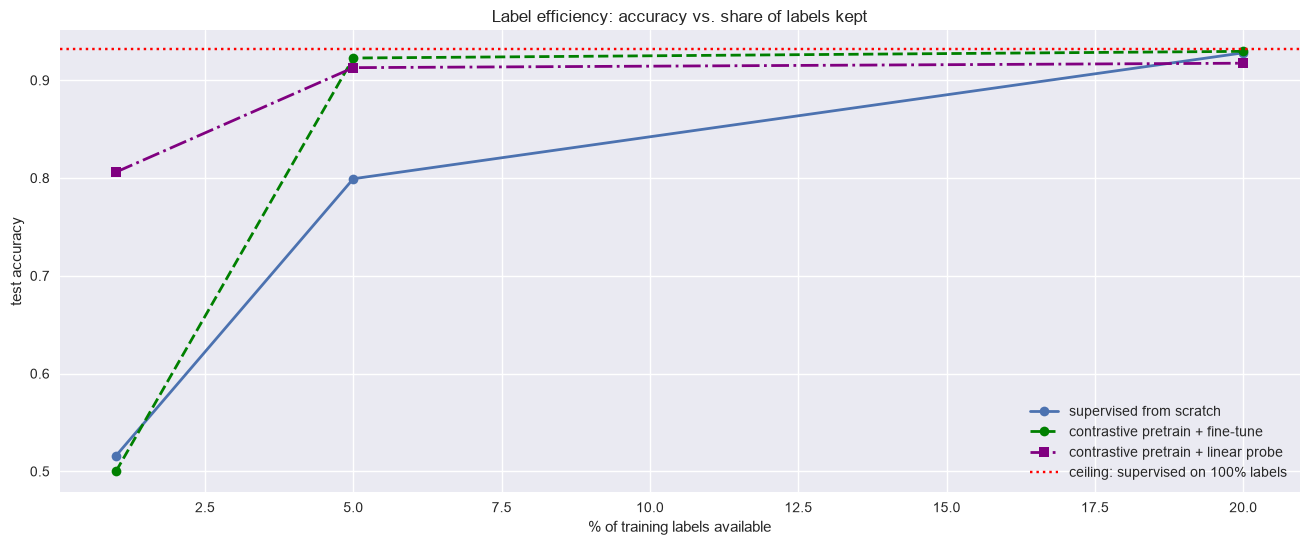

In [31]:
# how does the picture change as labels get scarcer or richer?
FRACTIONS = [0.01, 0.05, 0.20]

# the probe arm reuses features from the pristine pretrained encoder
with keras.device(DEVICE):
    feat_train = encoder_con.predict(X_train, batch_size=256, verbose=0)
    feat_test = encoder_con.predict(X_test, batch_size=256, verbose=0)

curve = {'scratch': [], 'fine-tune': [], 'probe': []}
for frac in FRACTIONS:
    m = make_labeled_split(y_train, frac, CFG.SEED)
    Xf, yf = X_train[m], y_train[m]
    ms = fit_classifier(Xf, yf, CFG.small_epochs, CFG.small_batch)
    curve['scratch'].append(test_accuracy(ms))
    enc = build_encoder(pooled=True)
    enc.set_weights(contrastive_weights)          # restart from the SAME pretraining
    mf = fit_classifier(Xf, yf, CFG.finetune_epochs, CFG.small_batch,
                        encoder=enc, lr=1e-4)
    curve['fine-tune'].append(test_accuracy(mf))
    clf = LogisticRegression(max_iter=2000).fit(feat_train[m], yf)
    curve['probe'].append(float(clf.score(feat_test, y_test)))
    print(f'{frac:.0%} labels ({m.sum()} series): '
          f'scratch {curve["scratch"][-1]:.3f}, '
          f'fine-tune {curve["fine-tune"][-1]:.3f}, '
          f'probe {curve["probe"][-1]:.3f}')

pct = [f * 100 for f in FRACTIONS]
plt.plot(pct, curve['scratch'], linewidth=2, marker='o',
         label='supervised from scratch')
plt.plot(pct, curve['fine-tune'], color='green', linestyle='--', linewidth=2,
         marker='o', label='contrastive pretrain + fine-tune')
plt.plot(pct, curve['probe'], color='purple', linestyle='-.', linewidth=2,
         marker='s', label='contrastive pretrain + linear probe')
plt.axhline(scores['supervised CNN (100% labels)'], color='red', linestyle=':',
            label='ceiling: supervised on 100% labels')
plt.title('Label efficiency: accuracy vs. share of labels kept')
plt.xlabel('% of training labels available')
plt.ylabel('test accuracy')
plt.legend()
plt.show()

This code investigates the impact of varying amounts of labeled data on model performance, comparing three different learning strategies: training from scratch, fine-tuning a pretrained encoder, and linear probing with a fixed pretrained encoder.

It defines `FRACTIONS` as a list containing the fractions of labels to use in each experiment: 1%, 5%, and 20%.

The code first extracts features from the entire training dataset using the contrastively pretrained encoder (`encoder_con`). These features will be used for linear probing, which doesn't require retraining the encoder.

A dictionary `curve` is initialized to store the test accuracies achieved by each learning strategy at different label fractions. The code then iterates through each fraction in `FRACTIONS`:
- It generates a labeled subset of the training data using `make_labeled_split`.
- **Training from Scratch:** A classifier is trained from scratch on this limited labeled dataset, and its test accuracy is recorded in `curve['scratch']`.
- **Fine-tuning:** The pretrained encoder's weights are reset to the original contrastive pretraining weights. Then, a new classifier is trained by fine-tuning the entire model (encoder + classifier) on the same limited labeled data, and its test accuracy is stored in `curve['fine-tune']`.
- **Linear Probing:** A logistic regression classifier is trained using the features extracted from the full training set (using the pretrained encoder) as input. This allows for evaluating the quality of the learned representations without modifying the encoder itself. The resulting accuracy is recorded in `curve['probe']`.

The test accuracies for each strategy and label fraction are printed to the console.

Finally, a plot is generated showing how the test accuracy varies with the percentage of training labels available for each learning strategy. The plot includes lines for training from scratch, fine-tuning, and linear probing, as well as a horizontal line representing the performance achieved when training on 100% of the labeled data (the "ceiling"). This visualization allows for a direct comparison of the label efficiency of different learning approaches.